### SVM Classification Using Ground-Truth Segmentation Features (ACDC)


This notebook trains a SVM classifier on the ACDC dataset using 7 clinical features
extracted from **ground-truth segmentation masks**.

The 7 features (LVEDV, LVESV, LVEF, RVEDV, RVESV, RVEF, MYO mass) are computed from the
`_gt.nii.gz` files at the ED and ES frames for all 150 ACDC subjects.

**Evaluation:**
- 4-fold stratified CV on 100 training subjects (same folds as all other experiments)
- Final model trained on all 100, tested on 50 held-out subjects
- Bootstrap confidence intervals (B=1000) on the test set

## 1. Imports

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import nibabel as nib
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    roc_auc_score,
    roc_curve,
)

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore", category=UserWarning)

import sklearn
print(f"numpy: {np.__version__}, pandas: {pd.__version__}, "
      f"sklearn: {sklearn.__version__}, nibabel: {nib.__version__}")

numpy: 2.4.2, pandas: 3.0.0, sklearn: 1.8.0, nibabel: 5.3.3


## 2. Configuration

Paths, class mapping, model hyperparameters, and the 4-fold CV splits.

The fold splits are the same ones used across all experiments in this thesis
so results are directly comparable.

In [2]:
# --- Paths ---
ACDC_ROOT    = Path(r"C:\Users\manoj\Desktop\Thesis\ACDC\ACDC\database")
TRAINING_DIR = ACDC_ROOT / "training"
TESTING_DIR  = ACDC_ROOT / "testing"

LABELS_TRAIN_CSV = Path(r"C:\Users\manoj\Desktop\Thesis\labels_acdc_5class.csv")
LABELS_TEST_CSV  = Path(r"C:\Users\manoj\Desktop\Thesis\labels_acdc_5class_test.csv")

OUT_DIR = Path(r"C:\Users\manoj\Desktop\Thesis\svm_gt_results")
FIG_DIR = OUT_DIR / "thesis_figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- Classes ---
CLASS_MAP    = {"NOR": 0, "MINF": 1, "DCM": 2, "HCM": 3, "RV": 4}
CLASS_NAMES  = {0: "NOR", 1: "MINF", 2: "DCM", 3: "HCM", 4: "RV"}
CLASS_LABELS = ["NOR", "MINF", "DCM", "HCM", "RV"]
CLASSES      = [0, 1, 2, 3, 4]
NUM_CLASSES  = 5

# --- Segmentation labels (ACDC standard) ---
RV_LABEL  = 1   # right ventricle
MYO_LABEL = 2   # myocardium
LV_LABEL  = 3   # left ventricle
MYO_DENSITY_G_PER_ML = 1.05  # standard myocardial density

# --- Features ---
FEATURE_COLS = [
    "LVEDV_ml", "LVESV_ml", "LVEF_pct",
    "RVEDV_ml", "RVESV_ml", "RVEF_pct",
    "MYO_mass_g",
]

# --- Reproducibility ---
SEED = 0
np.random.seed(SEED)

# --- SVM hyperparameters ---
# RBF kernel, C=10 and gamma='scale' are strong defaults for small tabular datasets.
# probability=True is required to compute predict_proba for AUC.
# class_weight='balanced' matches the RF setup.
MODEL_PARAMS = dict(
    C=10,
    kernel="rbf",
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=SEED,
)

train_ids_fold0 = [1,2,3,4,5,7,8,9,10,11,12,13,15,18,19,21,22,25,26,27,28,29,30,31,32,33,35,37,38,39,40,41,42,43,44,45,46,47,48,49,52,53,54,55,58,60,61,65,66,67,68,69,71,72,73,74,75,76,77,78,80,81,82,83,84,85,86,87,88,89,90,92,94,96,97]
val_ids_fold0   = [0,6,14,16,17,20,23,24,34,36,50,51,56,57,59,62,63,64,70,79,91,93,95,98,99]

train_ids_fold1 = [0,1,2,4,6,7,8,9,10,11,12,14,16,17,18,20,21,22,23,24,25,26,27,28,31,33,34,35,36,37,40,41,42,43,44,45,48,49,50,51,55,56,57,58,59,62,63,64,65,66,67,68,70,71,72,73,74,76,77,79,83,84,85,87,88,90,91,92,93,94,95,96,97,98,99]
val_ids_fold1   = [3,5,13,15,19,29,30,32,38,39,46,47,52,53,54,60,61,69,75,78,80,81,82,86,89]

train_ids_fold2 = [0,1,3,5,6,7,8,10,13,14,15,16,17,18,19,20,23,24,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,46,47,48,49,50,51,52,53,54,56,57,59,60,61,62,63,64,65,66,68,69,70,72,74,75,78,79,80,81,82,85,86,89,90,91,92,93,94,95,96,98,99]
val_ids_fold2   = [2,4,9,11,12,21,22,25,26,27,43,44,45,55,58,67,71,73,76,77,83,84,87,88,97]

train_ids_fold3 = [0,2,3,4,5,6,9,11,12,13,14,15,16,17,19,20,21,22,23,24,25,26,27,29,30,32,34,36,38,39,43,44,45,46,47,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,67,69,70,71,73,75,76,77,78,79,80,81,82,83,84,86,87,88,89,91,93,95,97,98,99]
val_ids_fold3   = [1,7,8,10,18,28,31,33,35,37,40,41,42,48,49,65,66,68,72,74,85,90,92,94,96]

FOLDS = [
    (train_ids_fold0, val_ids_fold0),
    (train_ids_fold1, val_ids_fold1),
    (train_ids_fold2, val_ids_fold2),
    (train_ids_fold3, val_ids_fold3),
]

# Quick sanity check
for f, (tr, va) in enumerate(FOLDS):
    assert len(tr) == 75 and len(va) == 25, f"Fold {f} size mismatch"
    assert set(tr) & set(va) == set(), f"Fold {f} overlap"
    assert set(tr) | set(va) == set(range(100)), f"Fold {f} missing subjects"

print(f"Output dir: {OUT_DIR}")
print(f"Figures dir: {FIG_DIR}")

Output dir: C:\Users\manoj\Desktop\Thesis\svm_gt_results
Figures dir: C:\Users\manoj\Desktop\Thesis\svm_gt_results\thesis_figures


## 3. Helper Functions

Functions for reading ACDC metadata, loading NIfTI masks, computing
volumes/features, and evaluating classification performance.

In [3]:
def read_info_cfg(info_path):
    """Parse ED/ES frame numbers and pathology Group from an ACDC Info.cfg file."""
    ed = es = group = None
    for line in Path(info_path).read_text().splitlines():
        line = line.strip()
        if line.startswith("ED:"):
            ed = int(line.split(":")[1].strip())
        elif line.startswith("ES:"):
            es = int(line.split(":")[1].strip())
        elif line.startswith("Group:"):
            group = line.split(":")[1].strip()
    if ed is None or es is None:
        raise ValueError(f"Missing ED/ES in {info_path}")
    return ed, es, group


def load_nifti(path):
    """Load a NIfTI file. Returns (data_array, voxel_spacing_mm)."""
    nii = nib.load(str(path))
    data = nii.get_fdata()
    voxel_mm = tuple(float(x) for x in nii.header.get_zooms()[:3])
    return data, voxel_mm


def volume_ml(mask_3d, label, voxel_mm):
    """Volume in mL for voxels matching `label`. Converts mm³ -> mL (÷1000)."""
    dx, dy, dz = voxel_mm
    voxel_vol_mm3 = dx * dy * dz
    voxel_count = np.sum(mask_3d == label)
    return float((voxel_count * voxel_vol_mm3) / 1000.0)


def compute_patient_features(mask_ed, mask_es, voxel_mm):
    """
    Compute 7 clinical features from ED and ES segmentation masks.
    Feature definitions follow Srikijkasemwat et al. (2025), Table 1.
    """
    # LV
    lvedv = volume_ml(mask_ed, LV_LABEL, voxel_mm)
    lvesv = volume_ml(mask_es, LV_LABEL, voxel_mm)
    lvef  = ((lvedv - lvesv) / (lvedv + 1e-8)) * 100.0

    # RV
    rvedv = volume_ml(mask_ed, RV_LABEL, voxel_mm)
    rvesv = volume_ml(mask_es, RV_LABEL, voxel_mm)
    rvef  = ((rvedv - rvesv) / (rvedv + 1e-8)) * 100.0

    # Myocardial mass (ED frame, density = 1.05 g/mL)
    myo_vol_ml = volume_ml(mask_ed, MYO_LABEL, voxel_mm)
    myo_mass_g = myo_vol_ml * MYO_DENSITY_G_PER_ML

    return dict(
        LVEDV_ml=float(lvedv),
        LVESV_ml=float(lvesv),
        LVEF_pct=float(lvef),
        RVEDV_ml=float(rvedv),
        RVESV_ml=float(rvesv),
        RVEF_pct=float(rvef),
        MYO_mass_g=float(myo_mass_g),
    )


def patient_dir_from_id(root, pid0):
    """0-based index -> patient directory. pid0=0 -> patient001."""
    return root / f"patient{pid0 + 1:03d}"


def compute_macro_specificity(cm):
    """Per-class specificity (one-vs-rest TN/(TN+FP)), then macro-average."""
    n_classes = cm.shape[0]
    total = cm.sum()
    specs = []
    for i in range(n_classes):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = total - tp - fn - fp
        spec = (tn / (tn + fp)) if (tn + fp) > 0 else np.nan
        specs.append(spec)
    specs = np.asarray(specs, dtype=np.float64)
    return specs, float(np.nanmean(specs))


def safe_proba_matrix(proba, model_classes, all_classes):
    """
    Align predict_proba output to the full class list.
    Needed because sklearn only returns columns for classes seen during fit.
    """
    out = np.zeros((proba.shape[0], len(all_classes)), dtype=np.float64)
    class_to_idx = {c: i for i, c in enumerate(model_classes)}
    for j, c in enumerate(all_classes):
        if c in class_to_idx:
            out[:, j] = proba[:, class_to_idx[c]]
    return out


def compute_metrics_multiclass(y_true, y_prob, classes):
    """Compute accuracy, macro F1/precision/recall, balanced acc, specificity, AUC."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = y_prob.argmax(axis=1)

    cm = confusion_matrix(y_true, y_pred, labels=classes)

    y_true_bin = label_binarize(y_true, classes=classes)
    try:
        auc_macro_ovr = roc_auc_score(
            y_true_bin, y_prob, average="macro", multi_class="ovr")
    except ValueError:
        auc_macro_ovr = np.nan

    acc             = accuracy_score(y_true, y_pred)
    f1_macro        = f1_score(y_true, y_pred, labels=classes, average="macro", zero_division=0)
    precision_macro = precision_score(y_true, y_pred, labels=classes, average="macro", zero_division=0)
    recall_macro    = recall_score(y_true, y_pred, labels=classes, average="macro", zero_division=0)
    bal_acc         = balanced_accuracy_score(y_true, y_pred)
    _, spec_macro   = compute_macro_specificity(cm)

    return dict(
        auc_macro_ovr=float(auc_macro_ovr),
        acc=float(acc),
        f1_macro=float(f1_macro),
        precision_macro=float(precision_macro),
        recall_macro=float(recall_macro),
        balanced_acc=float(bal_acc),
        specificity_macro=float(spec_macro),
        y_pred=y_pred,
        cm=cm,
    )


def bootstrap_summary(series):
    """Mean, std, 95% percentile CI."""
    x = pd.Series(series).dropna().astype(float).values
    if len(x) == 0:
        return {"mean": np.nan, "std": np.nan,
                "ci95_low": np.nan, "ci95_high": np.nan, "n_valid": 0}
    return {
        "mean":      float(np.mean(x)),
        "std":       float(np.std(x, ddof=1)) if len(x) > 1 else 0.0,
        "ci95_low":  float(np.percentile(x, 2.5)),
        "ci95_high": float(np.percentile(x, 97.5)),
        "n_valid":   int(len(x)),
    }


print("Helper functions defined.")

Helper functions defined.


## 4. Feature Extraction — Training Set (n=100)

For each patient: read Info.cfg → load ED and ES ground-truth masks → compute 7 features.

In [4]:
df_labels_train = pd.read_csv(LABELS_TRAIN_CSV)
label_map_train = dict(zip(df_labels_train["patient_id"],
                           df_labels_train["label"]))
print(f"Training labels: {len(label_map_train)} patients")

train_rows = []
for pid0 in range(100):
    pid_str = f"patient{pid0 + 1:03d}"
    pdir = patient_dir_from_id(TRAINING_DIR, pid0)
    assert pdir.exists(), f"Missing: {pdir}"

    ed_frame, es_frame, group = read_info_cfg(pdir / "Info.cfg")

    gt_ed_path = pdir / f"{pid_str}_frame{ed_frame:02d}_gt.nii.gz"
    gt_es_path = pdir / f"{pid_str}_frame{es_frame:02d}_gt.nii.gz"
    assert gt_ed_path.exists(), f"Missing GT ED: {gt_ed_path}"
    assert gt_es_path.exists(), f"Missing GT ES: {gt_es_path}"

    mask_ed, voxel_mm = load_nifti(gt_ed_path)
    mask_es, _        = load_nifti(gt_es_path)
    feats = compute_patient_features(mask_ed, mask_es, voxel_mm)

    label = label_map_train.get(pid_str)
    if label is None:
        label = CLASS_MAP.get(group)
    assert label is not None, f"No label for {pid_str}"

    row = {"patient_id": pid_str, "label": int(label), "group": group,
           "dx_mm": voxel_mm[0], "dy_mm": voxel_mm[1], "dz_mm": voxel_mm[2]}
    row.update(feats)
    train_rows.append(row)

df_train = pd.DataFrame(train_rows)
df_train.to_csv(OUT_DIR / "train_features_gt.csv", index=False)

print(f"Shape: {df_train.shape}")
print(f"\nClass distribution:")
for c in CLASSES:
    print(f"  {CLASS_NAMES[c]:5s}: {(df_train['label'] == c).sum()}")

print(f"\nFeature stats:")
print(df_train[FEATURE_COLS].describe().round(2).to_string())

Training labels: 100 patients
Shape: (100, 13)

Class distribution:
  NOR  : 20
  MINF : 20
  DCM  : 20
  HCM  : 20
  RV   : 20

Feature stats:
       LVEDV_ml  LVESV_ml  LVEF_pct  RVEDV_ml  RVESV_ml  RVEF_pct  MYO_mass_g
count    100.00    100.00    100.00    100.00    100.00    100.00      100.00
mean     164.61     99.06     46.38    152.99     85.88     46.73      129.96
std       74.27     78.76     19.92     55.15     52.47     17.89       51.01
min       49.27     19.36     10.48     47.37     10.32      1.92       34.28
25%      118.06     41.77     27.98    111.77     51.59     38.16       96.83
50%      149.01     64.11     53.65    152.01     70.08     48.41      123.64
75%      199.78    132.58     62.24    181.68    108.20     60.04      164.69
max      374.38    334.46     81.87    295.12    262.82     85.94      272.01


## 5. Feature Extraction — Test Set (n=50)

Same procedure, applied to patient101–patient150.

In [5]:
df_labels_test = pd.read_csv(LABELS_TEST_CSV)
label_map_test = dict(zip(df_labels_test["patient_id"],
                          df_labels_test["label"]))
print(f"Test labels: {len(label_map_test)} patients")

test_rows = []
for pid_abs in range(101, 151):
    pid_str = f"patient{pid_abs:03d}"
    pdir = TESTING_DIR / pid_str
    assert pdir.exists(), f"Missing: {pdir}"

    ed_frame, es_frame, group = read_info_cfg(pdir / "Info.cfg")

    gt_ed_path = pdir / f"{pid_str}_frame{ed_frame:02d}_gt.nii.gz"
    gt_es_path = pdir / f"{pid_str}_frame{es_frame:02d}_gt.nii.gz"
    assert gt_ed_path.exists(), f"Missing GT ED: {gt_ed_path}"
    assert gt_es_path.exists(), f"Missing GT ES: {gt_es_path}"

    mask_ed, voxel_mm = load_nifti(gt_ed_path)
    mask_es, _        = load_nifti(gt_es_path)
    feats = compute_patient_features(mask_ed, mask_es, voxel_mm)

    label = label_map_test.get(pid_str)
    if label is None and group is not None:
        label = CLASS_MAP.get(group)
    assert label is not None, f"No label for {pid_str}"

    row = {"patient_id": pid_str, "label": int(label), "group": group,
           "dx_mm": voxel_mm[0], "dy_mm": voxel_mm[1], "dz_mm": voxel_mm[2]}
    row.update(feats)
    test_rows.append(row)

df_test = pd.DataFrame(test_rows)
df_test.to_csv(OUT_DIR / "test_features_gt.csv", index=False)

print(f"Shape: {df_test.shape}")
print(f"\nClass distribution:")
for c in CLASSES:
    print(f"  {CLASS_NAMES[c]:5s}: {(df_test['label'] == c).sum()}")

print(f"\nFeature stats:")
print(df_test[FEATURE_COLS].describe().round(2).to_string())

Test labels: 50 patients
Shape: (50, 13)

Class distribution:
  NOR  : 10
  MINF : 10
  DCM  : 10
  HCM  : 10
  RV   : 10

Feature stats:
       LVEDV_ml  LVESV_ml  LVEF_pct  RVEDV_ml  RVESV_ml  RVEF_pct  MYO_mass_g
count     50.00     50.00     50.00     50.00     50.00     50.00       50.00
mean     176.58     98.60     50.74    171.55     94.17     46.56      133.74
std       71.06     79.59     22.20     67.85     50.67     12.47       51.44
min       73.91     19.93      7.57     59.76     30.99     11.62       44.58
25%      125.65     39.94     29.89    125.34     63.47     40.78      100.91
50%      147.90     64.44     57.37    152.01     78.53     46.22      128.28
75%      213.68    129.79     68.64    205.20    114.88     53.45      158.95
max      387.75    317.48     84.44    398.74    271.63     71.17      360.72


## 6. 4-Fold Cross-Validation

Pipeline per fold: `SimpleImputer(median) → StandardScaler → SVM`.

Train: (100, 7), Test: (50, 7)


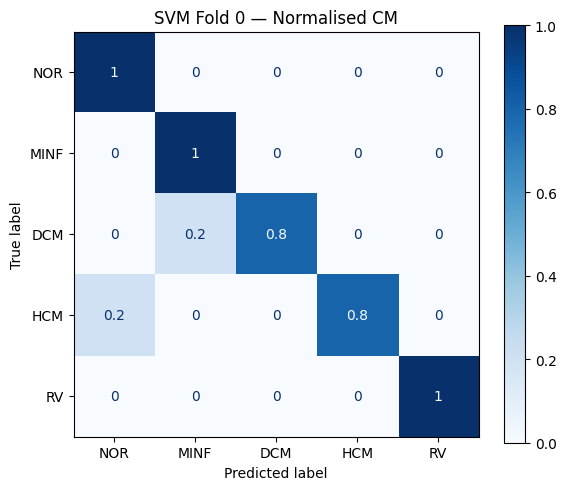

Fold 0: acc=0.920  F1=0.919  AUC=0.978


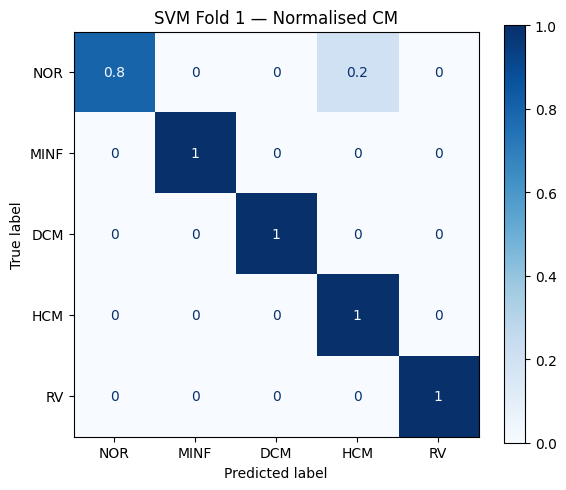

Fold 1: acc=0.960  F1=0.960  AUC=1.000


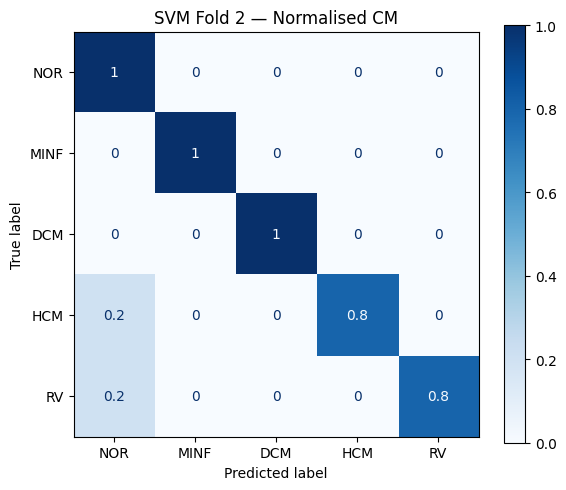

Fold 2: acc=0.920  F1=0.922  AUC=0.998


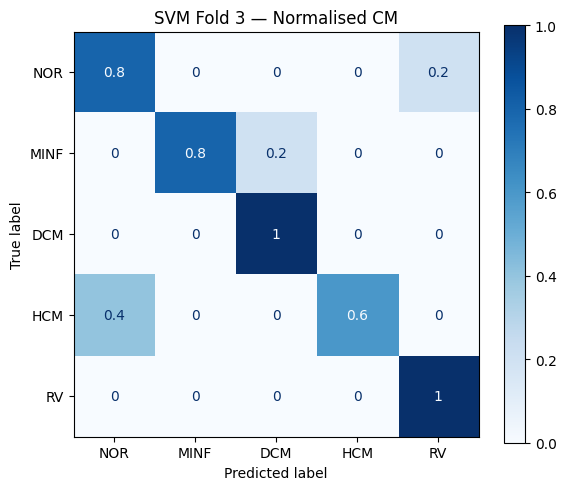

Fold 3: acc=0.840  F1=0.837  AUC=0.994

SVM — 4-FOLD CV RESULTS
  acc                    0.910 ± 0.050
  f1_macro               0.909 ± 0.052
  precision_macro        0.927 ± 0.043
  recall_macro           0.910 ± 0.050
  balanced_acc           0.910 ± 0.050
  specificity_macro      0.978 ± 0.013
  auc_macro_ovr          0.992 ± 0.010


In [6]:
X_tr_all = df_train[FEATURE_COLS].values
y_tr_all = df_train["label"].values.astype(int)
X_te = df_test[FEATURE_COLS].values
y_te = df_test["label"].values.astype(int)

print(f"Train: {X_tr_all.shape}, Test: {X_te.shape}")

cv_rows = []

for fold_idx, (train_ids, val_ids) in enumerate(FOLDS):
    fold_dir = OUT_DIR / f"fold_{fold_idx:02d}"
    fold_dir.mkdir(parents=True, exist_ok=True)

    X_tr, y_tr = X_tr_all[train_ids], y_tr_all[train_ids]
    X_va, y_va = X_tr_all[val_ids],   y_tr_all[val_ids]

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("svm", SVC(**MODEL_PARAMS)),
    ])
    model.fit(X_tr, y_tr)

    y_prob_va = safe_proba_matrix(
        model.predict_proba(X_va), model.classes_, CLASSES)
    met = compute_metrics_multiclass(y_va, y_prob_va, CLASSES)
    y_pred_va = met["y_pred"]

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_va, y_pred_va,
        display_labels=[CLASS_NAMES[c] for c in CLASSES],
        normalize="true", cmap="Blues", ax=ax)
    ax.set_title(f"SVM Fold {fold_idx} — Normalised CM")
    plt.tight_layout()
    plt.savefig(fold_dir / "confusion_matrix.png", dpi=150)
    plt.show()

    cv_rows.append({
        "fold":               fold_idx,
        "auc_macro_ovr":      met["auc_macro_ovr"],
        "acc":                met["acc"],
        "f1_macro":           met["f1_macro"],
        "precision_macro":    met["precision_macro"],
        "recall_macro":       met["recall_macro"],
        "balanced_acc":       met["balanced_acc"],
        "specificity_macro":  met["specificity_macro"],
    })

    print(f"Fold {fold_idx}: acc={met['acc']:.3f}  F1={met['f1_macro']:.3f}  "
          f"AUC={met['auc_macro_ovr']:.3f}")

# --- CV summary ---
cv_df = pd.DataFrame(cv_rows)
cv_df.to_csv(OUT_DIR / "cv_results.csv", index=False)

print(f"\n{'='*50}")
print("SVM — 4-FOLD CV RESULTS")
print(f"{'='*50}")
for col in ["acc", "f1_macro", "precision_macro", "recall_macro",
            "balanced_acc", "specificity_macro", "auc_macro_ovr"]:
    vals = cv_df[col].values
    print(f"  {col:<22} {np.mean(vals):.3f} ± {np.std(vals, ddof=1):.3f}")

## 7. Test Evaluation

Train on all 100 subjects, test on the 50 held-out subjects.

Test Accuracy     : 84.0%
Test Macro F1     : 83.9%
Test Macro Prec   : 84.1%
Test Macro Recall : 84.0%
Test Balanced Acc : 84.0%
Test Macro Spec   : 96.0%
Test Macro AUC    : 0.9675

              precision    recall  f1-score   support

         NOR       0.89      0.80      0.84        10
        MINF       0.78      0.70      0.74        10
         DCM       0.73      0.80      0.76        10
         HCM       0.90      0.90      0.90        10
          RV       0.91      1.00      0.95        10

    accuracy                           0.84        50
   macro avg       0.84      0.84      0.84        50
weighted avg       0.84      0.84      0.84        50



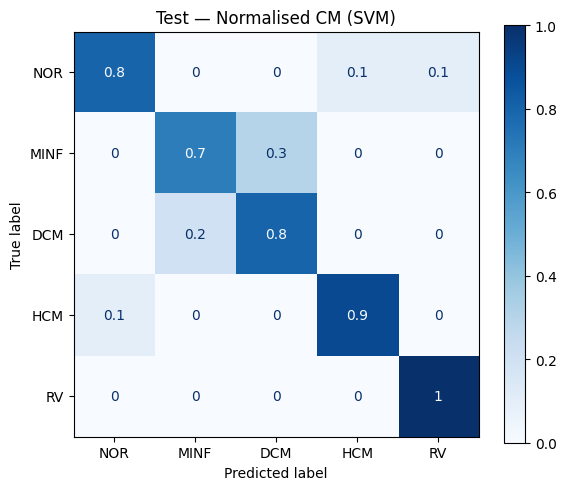

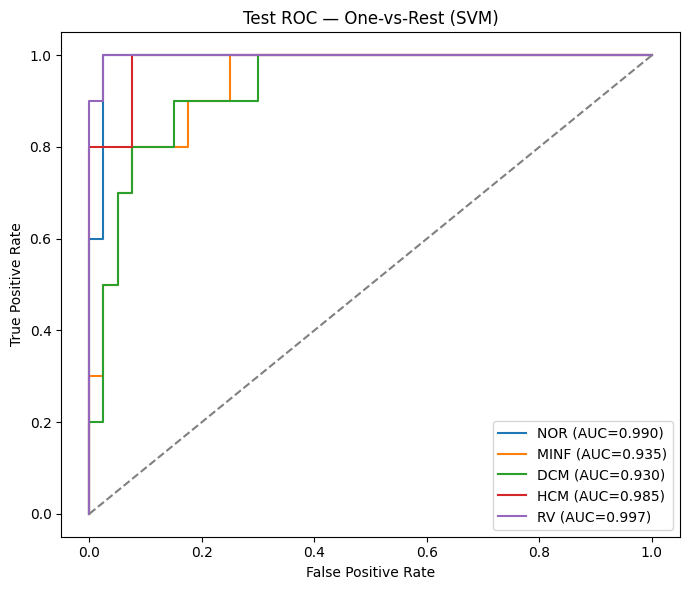

In [7]:
model_final = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("svm", SVC(**MODEL_PARAMS)),
])
model_final.fit(X_tr_all, y_tr_all)

y_prob_te = safe_proba_matrix(
    model_final.predict_proba(X_te), model_final.classes_, CLASSES)
met_te = compute_metrics_multiclass(y_te, y_prob_te, CLASSES)
y_pred_te = met_te["y_pred"]

print(f"Test Accuracy     : {met_te['acc']*100:.1f}%")
print(f"Test Macro F1     : {met_te['f1_macro']*100:.1f}%")
print(f"Test Macro Prec   : {met_te['precision_macro']*100:.1f}%")
print(f"Test Macro Recall : {met_te['recall_macro']*100:.1f}%")
print(f"Test Balanced Acc : {met_te['balanced_acc']*100:.1f}%")
print(f"Test Macro Spec   : {met_te['specificity_macro']*100:.1f}%")
print(f"Test Macro AUC    : {met_te['auc_macro_ovr']:.4f}")

print(f"\n{classification_report(y_te, y_pred_te, target_names=CLASS_LABELS)}")

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_te, y_pred_te,
    display_labels=[CLASS_NAMES[c] for c in CLASSES],
    normalize="true", cmap="Blues", ax=ax)
ax.set_title("Test — Normalised CM (SVM)")
plt.tight_layout()
plt.savefig(OUT_DIR / "test_confusion_matrix.png", dpi=150)
plt.show()

# ROC curves
y_te_bin = label_binarize(y_te, classes=CLASSES)
fig, ax = plt.subplots(figsize=(7, 6))
for i, c in enumerate(CLASSES):
    if len(np.unique(y_te_bin[:, i])) < 2:
        continue
    fpr, tpr, _ = roc_curve(y_te_bin[:, i], y_prob_te[:, i])
    auc_i = roc_auc_score(y_te_bin[:, i], y_prob_te[:, i])
    ax.plot(fpr, tpr, label=f"{CLASS_NAMES[c]} (AUC={auc_i:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Test ROC — One-vs-Rest (SVM)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUT_DIR / "test_roc_ovr.png", dpi=150)
plt.show()

## 8. Bootstrap Confidence Intervals (B=1000)

Resample the 50 test subjects with replacement 1000 times to get
mean ± std and 95% CIs for all metrics.

In [8]:
N_BOOT = 1000
rng = np.random.default_rng(seed=SEED)

boot_rows = []
n_test = len(y_te)

for b in range(N_BOOT):
    idx = rng.integers(0, n_test, size=n_test)
    y_true_b = y_te[idx]
    y_prob_b = y_prob_te[idx]
    met_b = compute_metrics_multiclass(y_true_b, y_prob_b, CLASSES)
    boot_rows.append({
        "bootstrap_id":      b,
        "auc_macro_ovr":     met_b["auc_macro_ovr"],
        "acc":               met_b["acc"],
        "f1_macro":          met_b["f1_macro"],
        "precision_macro":   met_b["precision_macro"],
        "recall_macro":      met_b["recall_macro"],
        "balanced_acc":      met_b["balanced_acc"],
        "specificity_macro": met_b["specificity_macro"],
    })

boot_df = pd.DataFrame(boot_rows)
boot_df.to_csv(OUT_DIR / "test_bootstrap_1000_metrics.csv", index=False)

metric_order = [
    ("acc",               "Accuracy"),
    ("precision_macro",   "Macro Precision"),
    ("recall_macro",      "Macro Recall"),
    ("f1_macro",          "Macro F1-score"),
    ("balanced_acc",      "Balanced Accuracy"),
    ("specificity_macro", "Macro Specificity"),
    ("auc_macro_ovr",     "Macro OvR AUC"),
]

boot_summary_rows = []
print(f"{'Metric':<22} {'Mean':>8} {'Std':>8} {'95% CI':>18}")
print("-" * 58)
for key, name in metric_order:
    s = bootstrap_summary(boot_df[key])
    boot_summary_rows.append({
        "metric": key, "display_name": name,
        "mean": s["mean"], "std": s["std"],
        "ci95_low": s["ci95_low"], "ci95_high": s["ci95_high"],
        "n_valid": s["n_valid"],
    })
    print(f"{name:<22} {s['mean']:8.3f} {s['std']:8.3f} "
          f"[{s['ci95_low']:.3f}, {s['ci95_high']:.3f}]")

boot_summary_df = pd.DataFrame(boot_summary_rows)
boot_summary_df.to_csv(OUT_DIR / "test_bootstrap_1000_summary.csv", index=False)

Metric                     Mean      Std             95% CI
----------------------------------------------------------
Accuracy                  0.841    0.052 [0.740, 0.940]
Macro Precision           0.842    0.054 [0.725, 0.940]
Macro Recall              0.841    0.053 [0.731, 0.938]
Macro F1-score            0.832    0.056 [0.718, 0.935]
Balanced Accuracy         0.841    0.053 [0.731, 0.938]
Macro Specificity         0.960    0.013 [0.934, 0.985]
Macro OvR AUC             0.968    0.014 [0.937, 0.991]


## 9. Thesis Figures

All figures saved as PNG (300 dpi) and PDF for the thesis report.

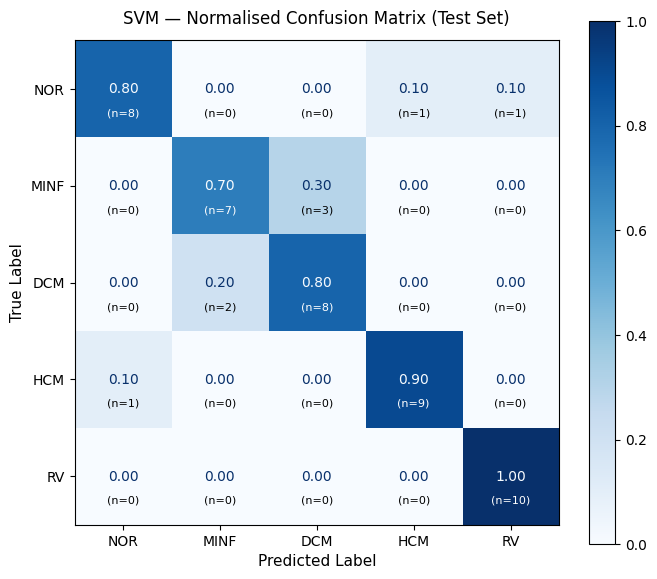

Saved: confusion_matrix_thesis.png / .pdf


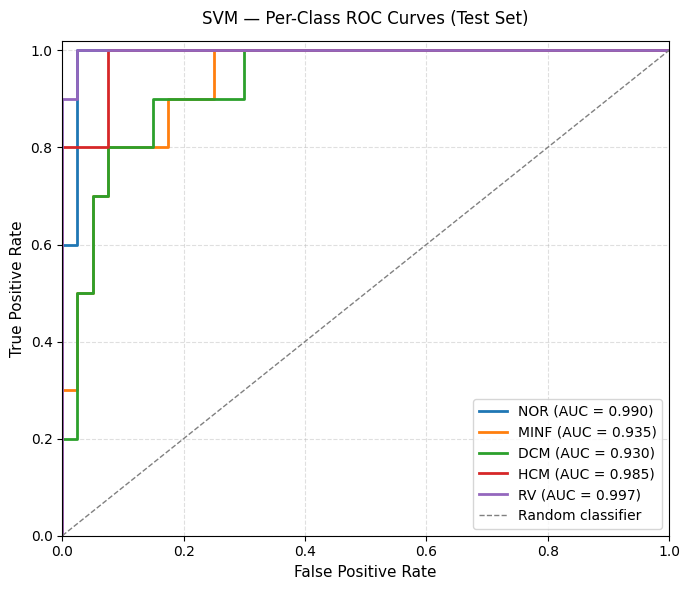

Saved: roc_curves_thesis.png / .pdf


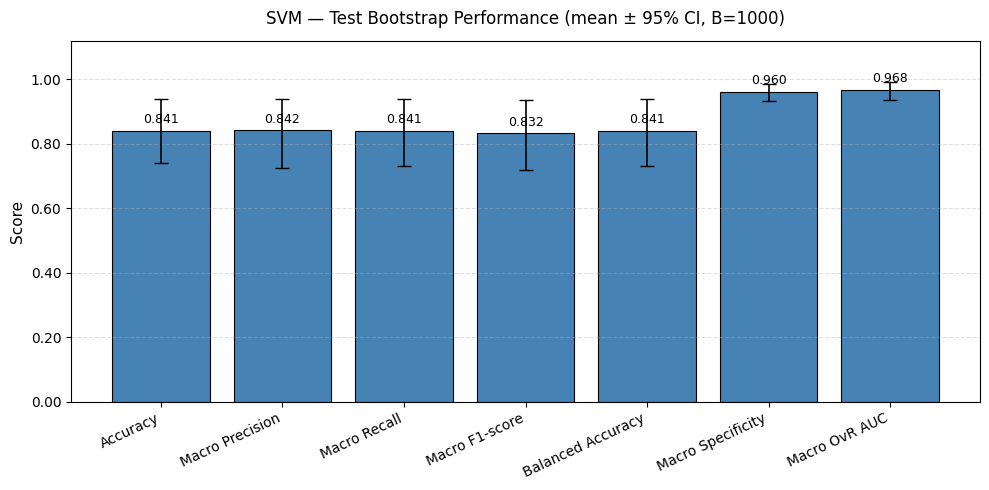

Saved: bootstrap_bar_thesis.png / .pdf


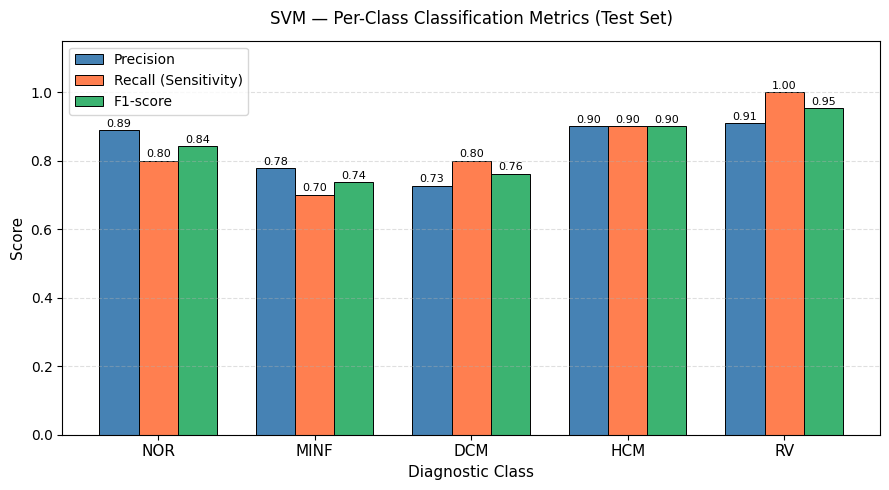

Saved: per_class_metrics_thesis.png / .pdf


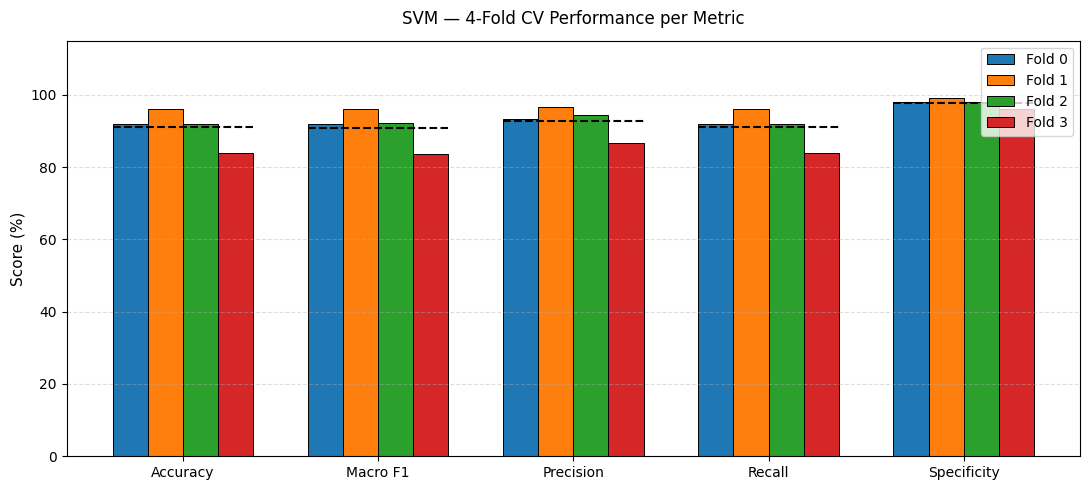

Saved: cv_fold_performance_thesis.png / .pdf

All figures saved to: C:\Users\manoj\Desktop\Thesis\svm_gt_results\thesis_figures


In [9]:
# ── Figure 1: Thesis-quality confusion matrix ──────────────────────
cm = met_te["cm"]

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm.astype(float) / cm.sum(axis=1, keepdims=True),
    display_labels=CLASS_LABELS,
)
disp.plot(ax=ax, cmap="Blues", colorbar=True, values_format=".2f")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i + 0.25,
            f"(n={cm[i, j]})",
            ha="center", va="center", fontsize=8,
            color="white" if cm[i, j] / cm[i].sum() > 0.5 else "black",
        )

ax.set_title("SVM — Normalised Confusion Matrix (Test Set)", fontsize=12, pad=12)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrix_thesis.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "confusion_matrix_thesis.pdf", bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix_thesis.png / .pdf")

# ── Figure 2: Per-class ROC curves ──────────────────────────────────
y_te_bin = label_binarize(y_te, classes=CLASSES)
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

fig, ax = plt.subplots(figsize=(7, 6))
for i, c in enumerate(CLASSES):
    if len(np.unique(y_te_bin[:, i])) < 2:
        continue
    fpr, tpr, _ = roc_curve(y_te_bin[:, i], y_prob_te[:, i])
    auc_i = roc_auc_score(y_te_bin[:, i], y_prob_te[:, i])
    ax.plot(fpr, tpr, color=colors[i], lw=2,
            label=f"{CLASS_NAMES[c]} (AUC = {auc_i:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1, label="Random classifier")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("SVM — Per-Class ROC Curves (Test Set)", fontsize=12, pad=12)
ax.legend(loc="lower right", fontsize=10)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / "roc_curves_thesis.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "roc_curves_thesis.pdf", bbox_inches="tight")
plt.show()
print("Saved: roc_curves_thesis.png / .pdf")

# ── Figure 3: Bootstrap CI bar chart ────────────────────────────────
names  = [r["display_name"] for r in boot_summary_rows]
means  = [r["mean"]         for r in boot_summary_rows]
ci_low = [r["ci95_low"]     for r in boot_summary_rows]
ci_hi  = [r["ci95_high"]    for r in boot_summary_rows]
err_lo = np.array(means) - np.array(ci_low)
err_hi = np.array(ci_hi) - np.array(means)
x_pos  = np.arange(len(names))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    x_pos, means,
    yerr=[err_lo, err_hi],
    capsize=5,
    color="steelblue", edgecolor="black", linewidth=0.8,
    error_kw={"elinewidth": 1.2, "ecolor": "black"},
)
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.015,
            f"{mean:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x_pos)
ax.set_xticklabels(names, rotation=25, ha="right", fontsize=10)
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_title("SVM — Test Bootstrap Performance (mean ± 95% CI, B=1000)",
             fontsize=12, pad=12)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / "bootstrap_bar_thesis.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "bootstrap_bar_thesis.pdf", bbox_inches="tight")
plt.show()
print("Saved: bootstrap_bar_thesis.png / .pdf")

# ── Figure 4: Per-class metrics bar chart ───────────────────────────
report = classification_report(
    y_te, y_pred_te,
    labels=CLASSES,
    target_names=CLASS_LABELS,
    output_dict=True,
    zero_division=0,
)
per_class_precision = [report[cls]["precision"] for cls in CLASS_LABELS]
per_class_recall    = [report[cls]["recall"]    for cls in CLASS_LABELS]
per_class_f1        = [report[cls]["f1-score"]  for cls in CLASS_LABELS]

x = np.arange(len(CLASS_LABELS))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width, per_class_precision, width, label="Precision",
       color="steelblue", edgecolor="black", linewidth=0.7)
ax.bar(x,          per_class_recall,   width, label="Recall (Sensitivity)",
       color="coral", edgecolor="black", linewidth=0.7)
ax.bar(x + width,  per_class_f1,       width, label="F1-score",
       color="mediumseagreen", edgecolor="black", linewidth=0.7)

for i, (p, r, f) in enumerate(zip(per_class_precision, per_class_recall, per_class_f1)):
    ax.text(i - width, p + 0.01, f"{p:.2f}", ha="center", fontsize=8)
    ax.text(i,         r + 0.01, f"{r:.2f}", ha="center", fontsize=8)
    ax.text(i + width, f + 0.01, f"{f:.2f}", ha="center", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_LABELS, fontsize=11)
ax.set_xlabel("Diagnostic Class", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_title("SVM — Per-Class Classification Metrics (Test Set)",
             fontsize=12, pad=12)
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / "per_class_metrics_thesis.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "per_class_metrics_thesis.pdf", bbox_inches="tight")
plt.show()
print("Saved: per_class_metrics_thesis.png / .pdf")

# ── Figure 5: CV fold performance bar chart ─────────────────────────
metric_cols = ["Accuracy", "Macro F1", "Precision", "Recall", "Specificity"]
fold_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

cv_display = pd.DataFrame([{
    "Accuracy":    round(row["acc"] * 100, 1),
    "Macro F1":    round(row["f1_macro"] * 100, 1),
    "Precision":   round(row["precision_macro"] * 100, 1),
    "Recall":      round(row["recall_macro"] * 100, 1),
    "Specificity": round(row["specificity_macro"] * 100, 1),
} for row in cv_df.to_dict("records")])

x_cv = np.arange(len(metric_cols))
n_folds = 4
bar_w   = 0.18

fig, ax = plt.subplots(figsize=(11, 5))
for fold_idx in range(n_folds):
    fold_vals = [cv_display.loc[fold_idx, col] for col in metric_cols]
    offset = (fold_idx - (n_folds - 1) / 2) * bar_w
    ax.bar(x_cv + offset, fold_vals, bar_w,
           label=f"Fold {fold_idx}",
           color=fold_colors[fold_idx], edgecolor="black", linewidth=0.7)

for j, col in enumerate(metric_cols):
    mean_val = cv_display[col].mean()
    ax.hlines(mean_val,
              j - n_folds / 2 * bar_w,
              j + n_folds / 2 * bar_w,
              colors="black", linewidths=1.5, linestyles="--")

ax.set_xticks(x_cv)
ax.set_xticklabels(metric_cols, fontsize=10)
ax.set_ylabel("Score (%)", fontsize=11)
ax.set_ylim(0, 115)
ax.set_title("SVM — 4-Fold CV Performance per Metric",
             fontsize=12, pad=12)
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / "cv_fold_performance_thesis.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "cv_fold_performance_thesis.pdf", bbox_inches="tight")
plt.show()
print("Saved: cv_fold_performance_thesis.png / .pdf")

print(f"\nAll figures saved to: {FIG_DIR}")